# BrushCue Example: Sparkle Vignette

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/sparkle_vignette.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/sparkle-vignette

In [ ]:
!pip install brushcue

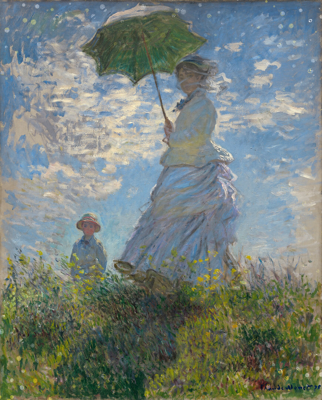

In [1]:
import brushcue
from PIL import Image
import io

input_image_1 = brushcue.composition_monet_women_with_parasol() # insert your own image here
string_constant_2 = brushcue.string_constant("let pos_x = f32(position.x);\nlet pos_y = f32(position.y);\nlet dims = vec2<f32>(textureDimensions(input_texture, 0));\nlet center = dims * 0.5;\nlet offset = vec2<f32>(pos_x, pos_y) - center;\nlet dist_from_center = length(offset) / length(center);\nlet dist_normalized = clamp(dist_from_center, 0.0, 1.0);\nlet density_curve = smoothstep(0.0, 1.0, dist_normalized * dist_normalized);\nlet cell_x = floor(pos_x / 80.0);\nlet cell_y = floor(pos_y / 80.0);\nvar closest_dist = 10000.0;\nvar closest_size = 0.5;\nfor(var i: i32 = -1; i <= 1; i = i + 1) {\n  for(var j: i32 = -1; j <= 1; j = j + 1) {\n    let neighbor_x = cell_x + f32(i);\n    let neighbor_y = cell_y + f32(j);\n    let rand_x = fract(sin(neighbor_x * 73.156 + neighbor_y * 94.673) * 45678.9234);\n    let rand_y = fract(sin(neighbor_x * 63.425 + neighbor_y * 84.712) * 56789.1234);\n    let rand_size = fract(sin(neighbor_x * 53.291 + neighbor_y * 74.563) * 34567.5678);\n    let sparkle_x = (neighbor_x + rand_x) * 80.0;\n    let sparkle_y = (neighbor_y + rand_y) * 80.0;\n    let dist = length(vec2<f32>(pos_x - sparkle_x, pos_y - sparkle_y));\n    if(dist < closest_dist) {\n      closest_dist = dist;\n      closest_size = rand_size;\n    }\n  }\n}\nlet base_noise = fract(sin(pos_x * 0.001 + pos_y * 0.0013) * 12345.6789);\nlet sparkle_threshold = step(mix(0.75, 0.35, density_curve) * sparkle_frequency, base_noise);\nlet min_radius = 3.0 * sparkle_size;\nlet max_radius = 25.0 * sparkle_size;\nlet sparkle_radius = mix(min_radius, max_radius, closest_size);\nlet sparkle_shape = smoothstep(sparkle_radius + 1.5, sparkle_radius - 1.5, closest_dist) * sparkle_threshold;\nlet is_gold = step(0.5, fract(sin(floor(pos_x / 80.0) * 73.156 + floor(pos_y / 80.0) * 94.673 + 300.0) * 12345.6789));\nlet gold = vec3<f32>(1.0, 0.84, 0.0);\nlet silver = vec3<f32>(0.95, 0.95, 0.95);\nlet sparkle_color = mix(silver, gold, is_gold);\nlet sparkle_intensity = sparkle_shape * 0.7;\nlet result = input.rgb + (sparkle_color * sparkle_intensity);\nreturn vec4<f32>(result, input.a);")
string_constant_3 = brushcue.string_constant("// No helpers needed")
get_color_profile_4 = brushcue.composition_color_profile(input_image_1)
bool_constant_5 = brushcue.bool_constant(True)
string_constant_6 = brushcue.string_constant("sparkle_size")
dictionary_create_7 = brushcue.dictionary_create()
string_constant_8 = brushcue.string_constant("sparkle_frequency")
float_constant_9 = brushcue.float_constant(0.5699999928474426)
float_constant_10 = brushcue.float_constant(1.409999966621399)
size_11 = brushcue.float_passthrough(float_constant_9)
frequency_12 = brushcue.float_passthrough(float_constant_10)
float_add_to_dictionary_13 = brushcue.float_add_to_dictionary(dictionary_create_7, string_constant_8, frequency_12)
float_add_to_dictionary_14 = brushcue.float_add_to_dictionary(float_add_to_dictionary_13, string_constant_6, size_11)
sparkle_effect_custom_15 = brushcue.composition_custom_transformer_shader(input_image_1, string_constant_2, string_constant_3, get_color_profile_4, get_color_profile_4, float_add_to_dictionary_14, bool_constant_5)

ctx = brushcue.Context()
result = sparkle_effect_custom_15.execute(ctx)
composition = result.as_composition()
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img.thumbnail((400, 400)) # remove this line for full resolution
img
